<a href="https://colab.research.google.com/github/six-eyes-dev/100-days-of-ml/blob/main/Lecture_13_End_to_End_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import libraries and dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv("/content/placement.csv")

## 2. Know your data:

In [ ]:
train.shape

(100, 4)

In [ ]:
train.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


### Removing un-necessary column

In [ ]:
# NOTE : train = train[:, 1:]   <- it's a numpy style, so it will throw error in Dataframe.
# That's why we are using iloc[]

train = train.iloc[:, 1:]


In [ ]:
train.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
train.isna().sum()

,0
cgpa,0
iq,0
placement,0


In [ ]:
train['placement'].value_counts()

,count
placement,
1,50
0,50


In [ ]:
train.nunique()

,0
cgpa,39
iq,71
placement,2


In [ ]:
train.groupby('placement')['cgpa'].mean()

,cgpa
placement,
0,5.056
1,6.926


In [ ]:
train.groupby('placement')['iq'].mean()

,iq
placement,
0,126.88
1,120.28


<Axes: xlabel='iq', ylabel='cgpa'>

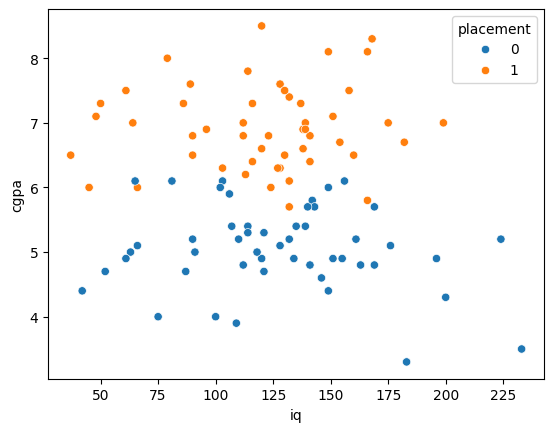

In [ ]:
sns.scatterplot(data=train, x='iq', y = 'cgpa', hue='placement')

## 3. Extract input and ouput Feature data:

In [ ]:
X = train.iloc[:, :-1]
y = train.iloc[:, -1]   # target column

## 4. Scale the Features:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

X

array([[ 0.71095807, -0.01459341],
       [-0.0799718 , -0.44233119],
       [-0.60725838, -0.0649155 ],
       [ 1.23824465,  0.21185601],
       [-0.16785289,  0.46346647],
       [ 0.97460136, -1.90167186],
       [-0.25573399,  0.48862751],
       [-0.87090167, -1.52425617],
       [ 0.0957904 ,  0.81572111],
       [-0.78302057, -1.44877303],
       [ 0.0079093 , -1.977155  ],
       [ 0.79883917,  0.36282228],
       [-0.51937728,  0.38798333],
       [ 0.35943369, -0.19072073],
       [ 0.0957904 , -0.51781433],
       [-0.78302057,  1.31894203],
       [-0.69513948,  2.52667224],
       [-2.36488031,  1.49506935],
       [-1.74971264, -0.59329747],
       [-0.69513948,  0.21185601],
       [ 0.53519588, -0.09007654],
       [ 0.97460136,  0.68991588],
       [-0.95878277, -0.09007654],
       [-1.13454496, -0.92039106],
       [-1.13454496, -0.0649155 ],
       [-0.87090167, -0.81974688],
       [ 0.88672027,  1.89764609],
       [ 0.0079093 ,  0.01056764],
       [-0.69513948,

## 5. Train test split

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
x_train

array([[-1.13454496, -0.92039106],
       [ 0.97460136, -1.90167186],
       [ 0.88672027, -0.29136491],
       [ 1.41400685, -0.87006897],
       [ 1.32612575, -1.57457826],
       [-0.78302057, -1.44877303],
       [ 0.0957904 , -1.47393408],
       [ 0.0079093 ,  0.01056764],
       [-0.69513948, -0.341687  ],
       [ 0.18367149, -0.26620387],
       [-0.87090167, -0.14039864],
       [-1.74971264, -1.22232362],
       [ 1.15036356, -0.19072073],
       [ 1.15036356,  0.33766124],
       [ 0.44731478, -0.84490793],
       [-0.51937728, -0.41717014],
       [ 0.88672027, -1.49909512],
       [-0.16785289,  0.46346647],
       [-1.74971264, -0.59329747],
       [ 1.58976904, -0.24104282],
       [ 1.41400685,  0.11121182],
       [-1.48606935,  1.92280714],
       [-0.78302057,  1.31894203],
       [-2.18911812,  2.75312165],
       [-1.83759373, -0.36684805],
       [ 0.0957904 , -1.07135734],
       [ 0.53519588,  0.36282228],
       [-1.13454496, -1.80102767],
       [ 0.88672027,

In [ ]:
x_test

array([[ 0.97460136,  0.68991588],
       [ 0.79883917,  0.38798333],
       [ 0.71095807, -0.84490793],
       [ 1.23824465,  0.21185601],
       [-0.51937728,  0.38798333],
       [-0.95878277, -0.09007654],
       [ 0.0079093 ,  0.63959379],
       [ 0.44731478,  0.16153392],
       [-0.69513948, -0.84490793],
       [-0.25573399,  0.41314438],
       [-0.25573399,  1.14281471],
       [ 0.88672027,  1.89764609],
       [-1.39818825, -2.05263813],
       [-0.95878277,  0.79056007],
       [-0.69513948,  2.52667224],
       [-0.25573399,  0.21185601],
       [ 0.0079093 , -1.44877303],
       [-0.51937728,  0.28733915],
       [ 0.53519588, -0.09007654],
       [ 0.27155259,  0.08605078]])

## 6. Train the model

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()


In [ ]:
clf.fit(x_train, y_train)


LogisticRegression()

In [ ]:
clf.predict(x_test)

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [ ]:
y_test

,placement
21,1
60,1
35,1
3,1
12,0
22,0
33,0
57,1
28,0
36,0


## 7. Evaluate the model

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(x_test)

accuracy_score(y_test, y_pred)

0.85

### Let's plot for the decision boundary

<Axes: >

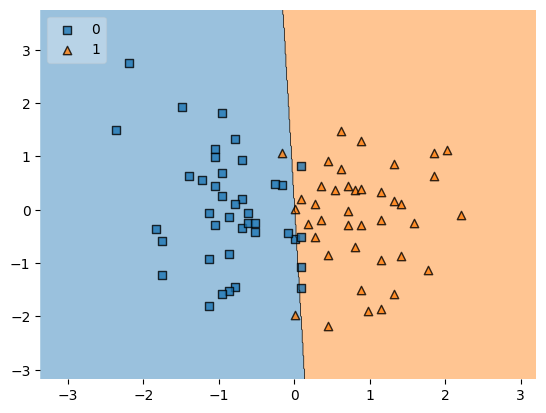

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)


## Deploy the model:


In [ ]:
# USING Pickle
